### Classification can be classified in 3 types

> *Classifcation is where we try to classify something as one thing or another*

1. Binary Classification
2. Multiclass Classification
3. Multilabel Classification

[batch_size, height, width, color_channel]

### Architecture of classification problem

📖  https://www.researchgate.net/profile/Nikolaos-Dimitriou/publication/338155860/figure/fig2/AS:862491118678016@1582645315260/The-architecture-of-the-classification-model-It-has-five-convolutional-blocks-that.ppm

> **Architecture for binary classification**

  - InputLayer shape -> Same as number of features
  - Hidden Layer(s) -> Problem specific min=1, max=unlimited
  - Neurons per hidden_layer -> problem specific; generally 10-100
  - Output Layer Shape -> 1 (one class or the other)  / 1 per class for multiclass
  - Hidden Activation -> Usually ReLU
  - Output Activation -> sigmoid  / softmax (multiclass)
  - Loss function -> BinaryCrossentropy / CategoricalCrossentropy
  - Optimizer -> SGD, Adam

In [34]:
# importing some librarires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

### creating data to view and fit

In [35]:
from sklearn.datasets import make_circles

# make 1000 samples
n_samples = 1000

# create circles
X, y = make_circles(n_samples, 
                    noise=0.03, 
                    random_state=42) 

In [ ]:
# check out the features and labels
X[:5], y[:5]

In [37]:
# unique labels
np.unique(y)  # binary classification

array([0, 1])

In [38]:
circles = pd.DataFrame({"X0": X[:, 0], "X1": X[:, 1], "label": y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


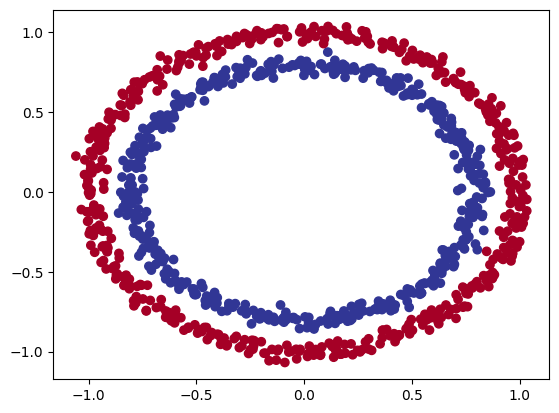

In [39]:
# visulaize the data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.show()

In [40]:
# inmpu and output shapes
X.shape, y.shape

((1000, 2), (1000,))

In [41]:
# first example of a data
X[0], y[0]

(array([0.75424625, 0.23148074]), 1)

### Steps in modelling with TensorFlow

1. Create the model
2. Compile the model
3. Fit the model
4. Evaluate the model
5. Tweak
6. Evaluate...

In [42]:
# set random seed
tf.random.set_seed(42)

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.BinaryCrossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["accuracy"]) 

# 3. Fit the model
history = model.fit(X, y, epochs=10)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4820 - loss: 6.3986   
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 6.2368 
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4430 - loss: 5.2340 
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4650 - loss: 4.7969 
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4770 - loss: 4.6947 
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 7.9712 
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 7.9712 
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 7.9712 
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 7.9712 
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 7.9712 


In [43]:
# 4. Evaluate the model
model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 7.9712  


[7.971191883087158, 0.5]

In [44]:
## lets try with more epochs
model.fit(X, y, epochs=100, verbose=0)
model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 7.9712 


[7.971191883087158, 0.5]

In [45]:
# tweka the model with adding extra layer
# set random seed   
tf.random.set_seed(42)

# 1. Create the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["accuracy"]) 

# 3. Fit the model
history = model_2.fit(X, y, epochs=100, verbose=0)

In [46]:
# evaluate the model
model_2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4180 - loss: 0.6932  


[0.6932287216186523, 0.4180000126361847]

In [47]:
circles['label'].value_counts()

label
1    500
0    500
Name: count, dtype: int64

### Improving our model

Let's look into our bag of tricks to see how can we improve our model.

1. create a model - we can increase the hidden unit with the layer.
2. compile a model - might use dfferent optimization fn (Adam).
3. fit a model - perhaps we fit out model for longer epochs

In [48]:
# create model 3
tf.random.set_seed(42)  

# 1. Create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# 3. Fit the model
history = model_3.fit(X, y, epochs=200, verbose=0)

In [49]:
# evalate the model
model_3.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4740 - loss: 0.6939  


[0.6938524842262268, 0.4740000069141388]

In [50]:
# plot decision boundary   
def plot_decision_boundary(model, X, y):
    ''' 
    plot decision boundry created by a model predicting on X.
    This function was inspired by two resources:
    1. https://cs231n.github.io/convolutional-networks/
    2. https://github.com/GokuMohandas/Made-With-ML
    '''
    
    # define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # create X value (we're going to make predictions on)
    x_in = np.c_[xx.ravel(), yy.ravel()]  # stacxk 2D array together
    
    # Make predictions
    y_pred = model.predict(x_in)
    
    # check for multiclass
    if len(y_pred[0]) > 1:
        print('doing multiclass classification')
        # we have to reshape our prediction to get them ready for plotting
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    
    else:
        print('doing binary classification')
        y_pred = np.round(y_pred).reshape(xx.shape)
        
    # plot the decision boundary
    plt.contourf(xx, yy, y_pred, 
                 cmap=plt.cm.RdYlBu, 
                 alpha=0.7)
    
    plt.scatter(X[:, 0], X[:, 1],
                c=y, s=40,
                cmap=plt.cm.RdYlBu)
    
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

In [51]:
# plot decision boundary   
def plot_decision_boundary(model, X, y):
    ''' 
    plot decision boundry created by a model predicting on X.
    This function was inspired by two resources:
    1. https://cs231n.github.io/convolutional-networks/
    2. https://github.com/GokuMohandas/Made-With-ML
    '''
    
    # define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # create X value (we're going to make predictions on)
    x_in = np.c_[xx.ravel(), yy.ravel()]  # stacxk 2D array together
    
    # Make predictions
    y_pred = model.predict(x_in)
    
    # check for multiclass
    if len(y_pred[0]) > 1:
        print('doing multiclass classification')
        # we have to reshape our prediction to get them ready for plotting
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    
    else:
        print('doing binary classification')
        y_pred = np.round(y_pred).reshape(xx.shape)
        
    # plot the decision boundary
    plt.contourf(xx, yy, y_pred, 
                 cmap=plt.cm.RdYlBu, 
                 alpha=0.7)
    
    plt.scatter(X[:, 0], X[:, 1],
                c=y, s=40,
                cmap=plt.cm.RdYlBu)
    
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step
doing binary classification


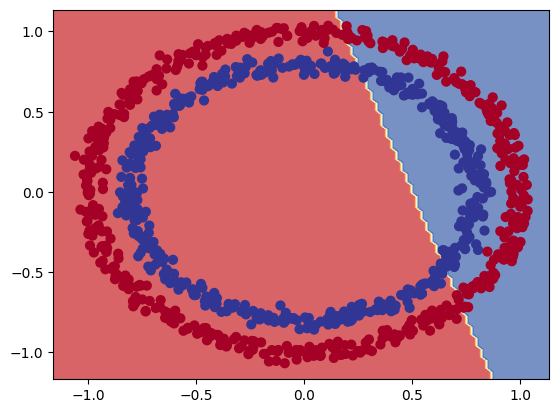

In [52]:
# check out the predictions our model is making
plot_decision_boundary(model=model_3,
                       X=X,
                       y=y)

As our model is predicting is straight lin, may we use it for regression

In [53]:
tf.random.set_seed(42)

# create some regression data
X_regression = tf.range(0, 1000, 5)
y_regression = tf.range(100, 1100, 5) # y = X + 100

# split into train and test
X_reg_train = X_regression[:150]
X_reg_test = X_regression[150:]
y_reg_train = y_regression[:150]
y_reg_test = y_regression[150:]

# # fit our model to regression data
# model_3.fit(X_reg_train, y_reg_train, epochs=100)

Oh wait... we compiled our model for binary classification problem.

But.. we're now working on regression pronlem, let's chaange our model to suit our data...

In [54]:
## recreate the model again

# set random seed
tf.random.set_seed(42)

# 1. create a model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. compile the models
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

# Reshape X_reg_train and y_reg_train for the Dense layer
X_reg_train_reshaped = tf.expand_dims(X_reg_train, axis=-1)
y_reg_train_reshaped = tf.expand_dims(y_reg_train, axis=-1)

# fit the model
model_3.fit(X_reg_train_reshaped, y_reg_train_reshaped, epochs=100) # Added epochs for better training

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 472.9293 - mae: 472.9293  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 393.9055 - mae: 393.9055 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 313.3417 - mae: 313.3417 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 229.4372 - mae: 229.4372 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 140.5745 - mae: 140.5745 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 56.9140 - mae: 56.9140
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 66.8483 - mae: 66.8483 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 75.7477 - mae: 75.7477
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 55.5198 - mae: 55.5198
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 43.2236 - mae: 43.2236 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 45.8265 - mae: 45.8265
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 41.7432 - mae: 41.7432
Epoch 13/100
5

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


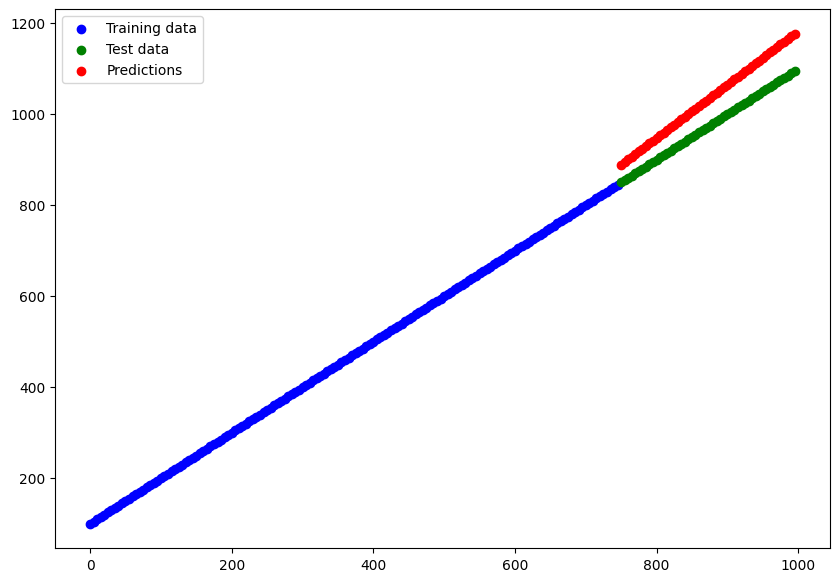

In [55]:
# make prediction with our trined model
y_reg_pred = model_3.predict(X_reg_test)

# plot the model prediction against our regression data
plt.figure(figsize=(10,7))
plt.scatter(X_reg_train, y_reg_train,
            c='b',
            label="Training data")
plt.scatter(X_reg_test, y_reg_test,
            c='g', label='Test data')
plt.scatter(X_reg_test, y_reg_pred,
            c='r', label='Predictions')
plt.legend();

### The Missing piece is Non-Linearity

What could we draw if you had an unlimited amount of straight (linear) and non-staright (non-linear) lines?

In [56]:
# from IPython.core import history
# creating the model_4

# set random seed
tf.random.set_seed(42)

# 1. create a model
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear)
])

# compile the model
model_4.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),    # 'Adam' could be written Either way but first way give us the freedom to change learning rate)
                metrics=['accuracy'])

# fit the model
history = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4850 - loss: 6.3044   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 6.2367 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4860 - loss: 6.2171 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4870 - loss: 6.1934 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4890 - loss: 6.1764 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4890 - loss: 6.1739 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4890 - loss: 6.1727 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4900 - loss: 6.1625 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4890 - loss: 6.1395 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4860 - loss: 6.1342 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4860 - loss: 6.1326 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

/var/folders/0b/_fz3pln11xz8q6vfw486xw4r0000gn/T/ipykernel_40230/4130655511.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c='y', cmap=plt.cm.RdYlBu);


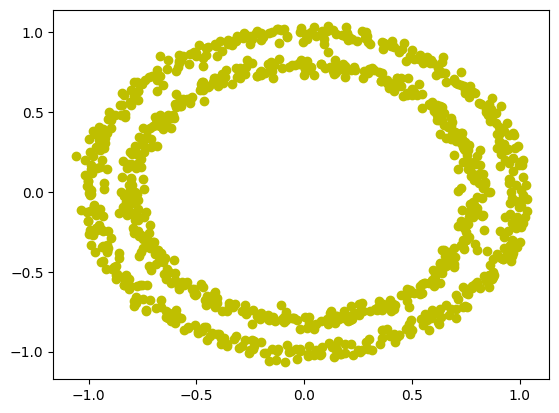

In [57]:
# check out the model
plt.scatter(X[:, 0], X[:, 1], c='y', cmap=plt.cm.RdYlBu);

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step
doing binary classification


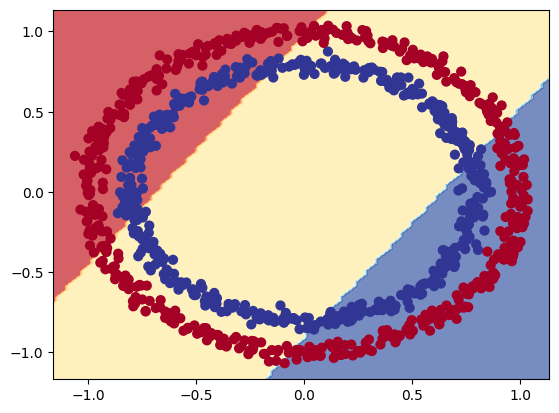

In [58]:
# check the desicion boundaries
plot_decision_boundary(model=model_4,
                       X=X,
                       y=y)

Let's try buildingh our first model with non linear activation function

In [60]:
# set random seed
tf.random.set_seed(42)

# 1. create a model with non-linear activation
model_5 = tf.keras.Sequential({
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
})

# 2. compile the model
model_5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

# 3. fit the model
history = model_5.fit(X, y, epochs=100)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4610 - loss: 4.5065   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4590 - loss: 4.4676 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4610 - loss: 4.4122 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4640 - loss: 4.3832 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4640 - loss: 4.3546 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4640 - loss: 4.3352 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4660 - loss: 4.2989 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4660 - loss: 4.2562
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4680 - loss: 4.2059
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4690 - loss: 4.1578 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4690 - loss: 4.1134 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

In [64]:
# time to implement multilayer neural network from tensorflow playground
# set random seed
tf.random.set_seed(42)

# 1. create a model with non-linear activation
model_6 = tf.keras.Sequential({
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1)
})

# 2. compile the model
model_6.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

# 3. fit the model
history = model_6.fit(X, y, epochs=100)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5000 - loss: 4.9772
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 4.2489 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 2.8953 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.9403 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.9916 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.9334 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.9070 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.8855 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.8671 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.8512
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.8374 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

In [65]:
# evaluate the model
model_5.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4720 - loss: 0.9612  


[0.9611626267433167, 0.47200000286102295]

In [67]:
# time to implement multilayer neural network from tensorflow playground
# set random seed
tf.random.set_seed(42)

# 1. create a model with non-linear activation
model_7 = tf.keras.Sequential({
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation="sigmoid")
})

# 2. compile the model
model_7.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

# 3. fit the model
history = model_7.fit(X, y, epochs=100)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4980 - loss: 0.7010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4980 - loss: 0.6983 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4530 - loss: 0.6967
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4660 - loss: 0.6956
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4940 - loss: 0.6946
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4920 - loss: 0.6939
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4940 - loss: 0.6933
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4890 - loss: 0.6929
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4930 - loss: 0.6925
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4900 - loss: 0.6922
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4870 - loss: 0.6918
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [68]:
# evaluate our model
model_7.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9720 - loss: 0.2867  


[0.28674644231796265, 0.972000002861023]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step
doing binary classification


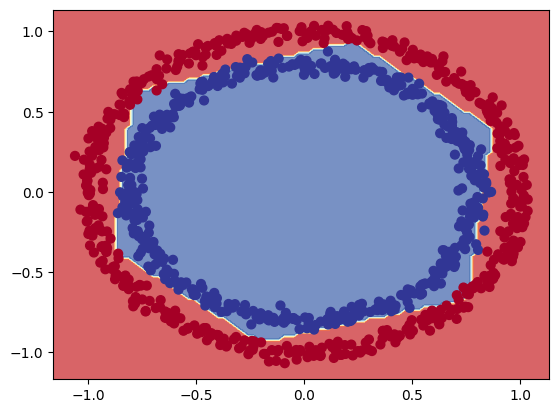

In [69]:
# let's visualise our incredible metrics
plot_decision_boundary(model_7, X, y)

**Question**: What's wrong with the prediction we made? Are we really evaluating our model correctly? *Hint*: What data did the model learn on and what data did we predict on?

**NOTE**: The combination of **linear(straight line) and non-linear(non-straight line)** is one of the key fundamentals of neural network.

Now we've discussed the concept of linear and non-linear functions (or lines) let's see the in action.

In [70]:
# create a toy tensor (similar to the data we passes into our model)
A = tf.cast(tf.range(-10, 10), tf.float32)
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

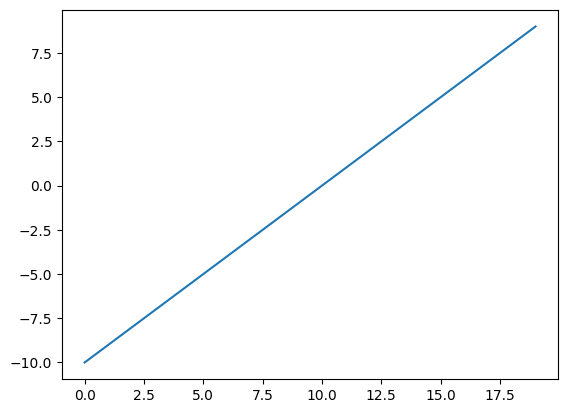

In [71]:
## visulaise our toy tensor
plt.plot(A);

In [72]:
# lets start by replicating sigmoid - sigmoid(x) = 1 / (1 + exp(-x))
def sigmoid(x):
  return 1 / (1 + tf.exp(-x))

# use sigmoid on our toy tensor
sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397872e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726233e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105860e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

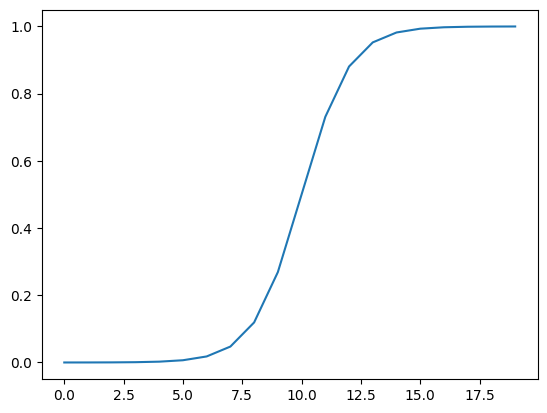

In [73]:
# plot out toy tensor A transformed by sigmoid
plt.plot(sigmoid(A));

In [74]:
# replicate the same for relu
def relu(x):
  return tf.maximum(0, x)

# pass our toy tensor to custom relu
relu(A)


<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

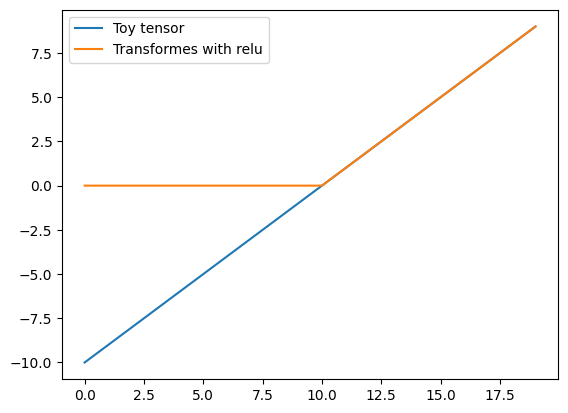

In [75]:
# visualise the relu
plt.plot(A, label='Toy tensor')
plt.plot(relu(A), label='Transformes with relu')
plt.legend();

In [76]:
# for the sake of completion lets try a linear activation function
# returns the input unmodified
tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

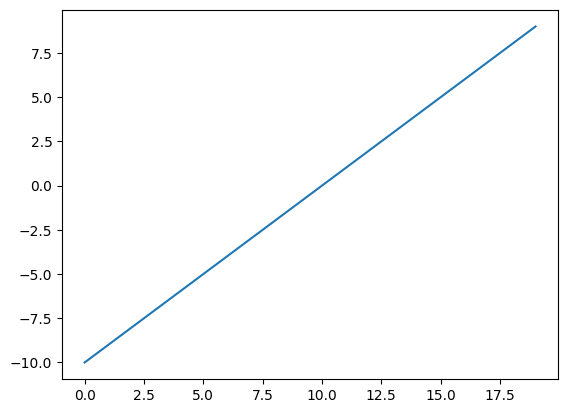

In [77]:
# plot this
plt.plot(tf.keras.activations.linear(A))

In [78]:
# Does A even change?
A == tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])>

### It's time to improve our classification model

so far we've been training and testing on the same dataset...

However, In machne learning this is basically as sin.

So let's create a training and test set.

In [80]:
# Cheeck how many examples we have
len(X)

1000

In [82]:
## random split into train and test
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [83]:
# lets recreate the model to fit omn training data and predicting on test data
# set random seed
tf.random.set_seed(42)

# 1. create a model
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. compile the model
model_8.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=['accuracy'])

# # 3. fit the model
# history = model_8.fit(X_train, y_train, epochs=25)

In [84]:
# # evaluate the model on test data
# model_8.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step
doing binary classification


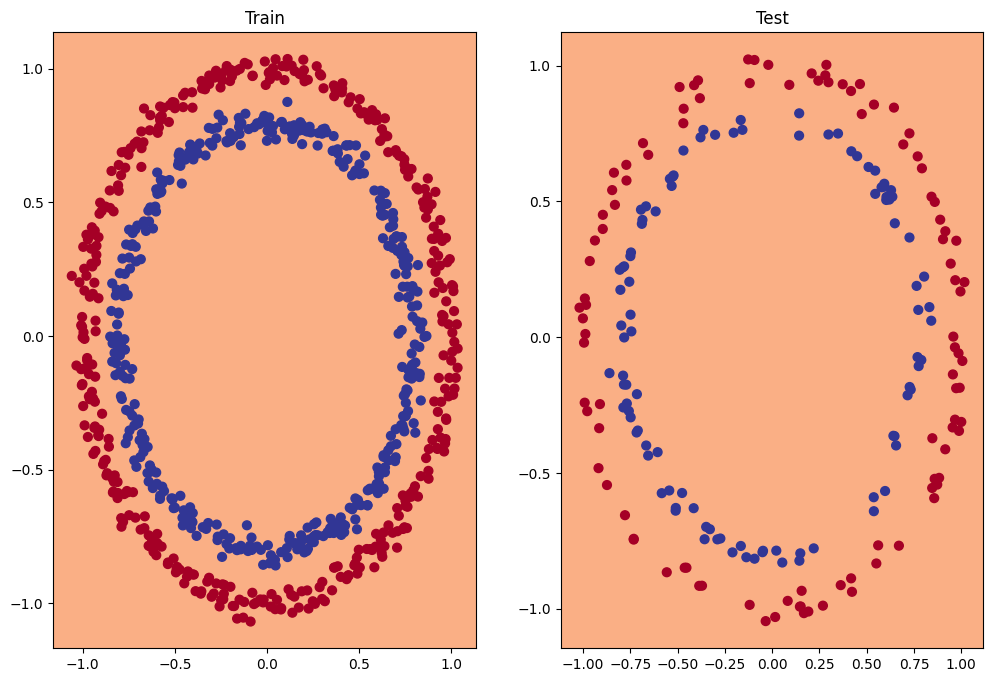

In [85]:
# plotting the decision boundary for the training and test set
plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_8,
                       X=X_train,
                       y=y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_8,
                       X=X_test,
                       y=y_test)
plt.show()

In [87]:
model_8.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (32, 4)                │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (32, 4)                │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (32, 1)                │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37 (148.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 0 (0.00 B)

### plot the loss (or training) curves

In [88]:
# convert the history data into nice tabular format
pd.DataFrame(history.history)

,accuracy,loss
0,0.498,0.700984
1,0.498,0.698349
2,0.453,0.696722
3,0.466,0.695552
4,0.494,0.694626
...,...,...
95,0.965,0.307092
96,0.966,0.302864
97,0.966,0.298667
98,0.967,0.294598


Text(0.5, 1.0, 'Model_8 loss curves')

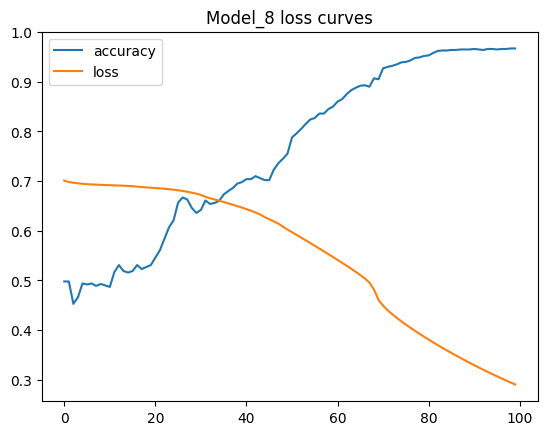

In [89]:
# plot the loss curves
pd.DataFrame(history.history).plot()
plt.title('Model_8 loss curves')

### Finding the best learning rate

To find the ideal lerning rate (the leaning rate where the loss decreases the most during training) we're going to use the following steps:
* A learning rate **callback** - you can think of a callback as an extra piece of functionaliy, you can add to your *while* training.
* Another model (we could use the same model above, but we're practicing building model here).
* A modified loss curve plot.

In [91]:
# set random seed
tf.random.set_seed(42)

# 1. crate a model (same as model_8)
model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 2. compile a model
model_9.compile(loss='binary_crossentropy',
                optimizer="Adam",
                metrics=['accuracy'])

# create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# fit the model
history_9 = model_9.fit(X_train,
                        y_train,
                        epochs=100,
                        callbacks=[lr_scheduler])  # can pass the multiple callbacks and it should be passed as a list



Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4900 - loss: 0.7334 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4925 - loss: 0.7316 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4925 - loss: 0.7297 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4913 - loss: 0.7277 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4913 - loss: 0.7255 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4938 - loss: 0.7233 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4938 - loss: 0.7209 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4900 - loss: 0.7184 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4900 - loss: 0.7159 - learning_

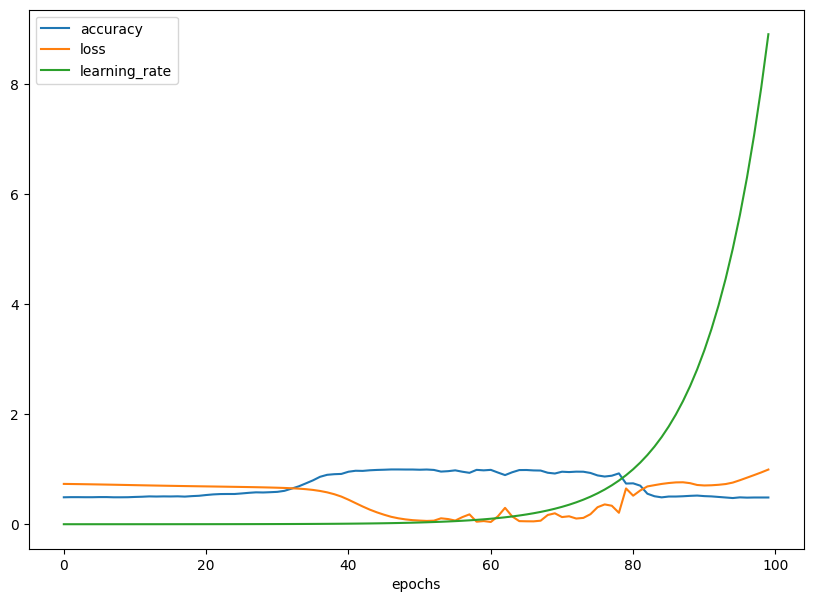

In [92]:
# cheeckout the history
pd.DataFrame(history_9.history).plot(figsize=(10,7), xlabel="epochs");

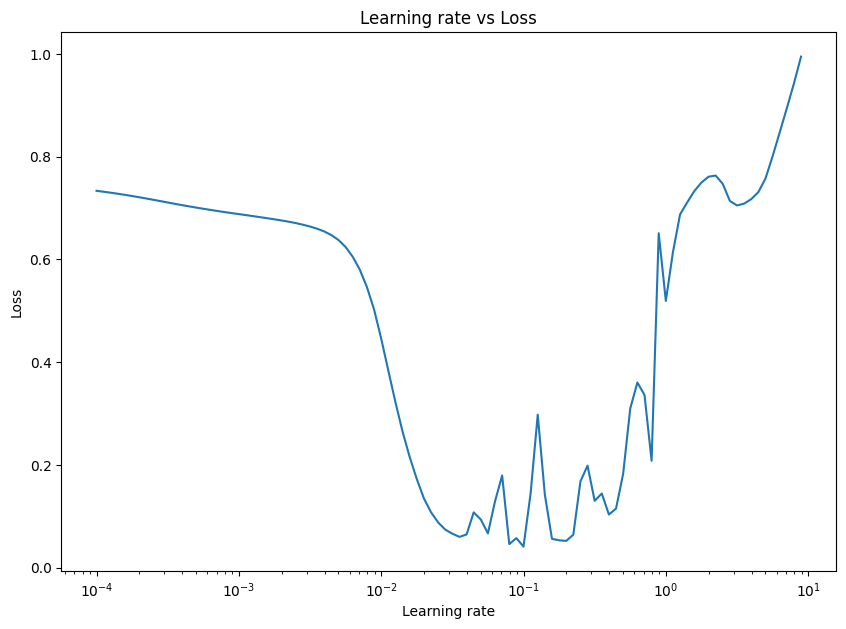

In [93]:
# plot learning rate vs loss
lrs = 1e-4 * (10 ** (tf.range(100)/20))
plt.figure(figsize=(10,7))
plt.semilogx(lrs, history_9.history["loss"])
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.title('Learning rate vs Loss')
plt.show()

In [94]:
# example of other typical learning rate
10**0, 10**-1, 10**-2, 10**-3, 1e-4

(1, 0.1, 0.01, 0.001, 0.0001)

In [95]:
# lets try using a higher *ideal* learning rate with the same model
# set random seed
tf.random.set_seed(42)

# 1. crate a model (same as model_8)
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 2. compile a model
model_10.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                metrics=['accuracy'])

# fit the model
history_10 = model_10.fit(X_train,
                        y_train,
                        epochs=20)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5138 - loss: 0.6951
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5825 - loss: 0.6779
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6125 - loss: 0.6628
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6625 - loss: 0.6359 
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7425 - loss: 0.5897 
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7525 - loss: 0.5410 
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7650 - loss: 0.5124 
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7825 - loss: 0.4619 
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8637 - loss: 0.3731 
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9212 - loss: 0.2969 
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9450 - loss: 0.2306 
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9

In [98]:
# evaluate model 10 on test dataset
model_10.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9850 - loss: 0.0620  


[0.062014564871788025, 0.9850000143051147]

In [99]:
# evaluate model 8 on test dataset
model_8.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5050 - loss: 0.7098  


[0.7098388671875, 0.5049999952316284]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step
doing binary classification


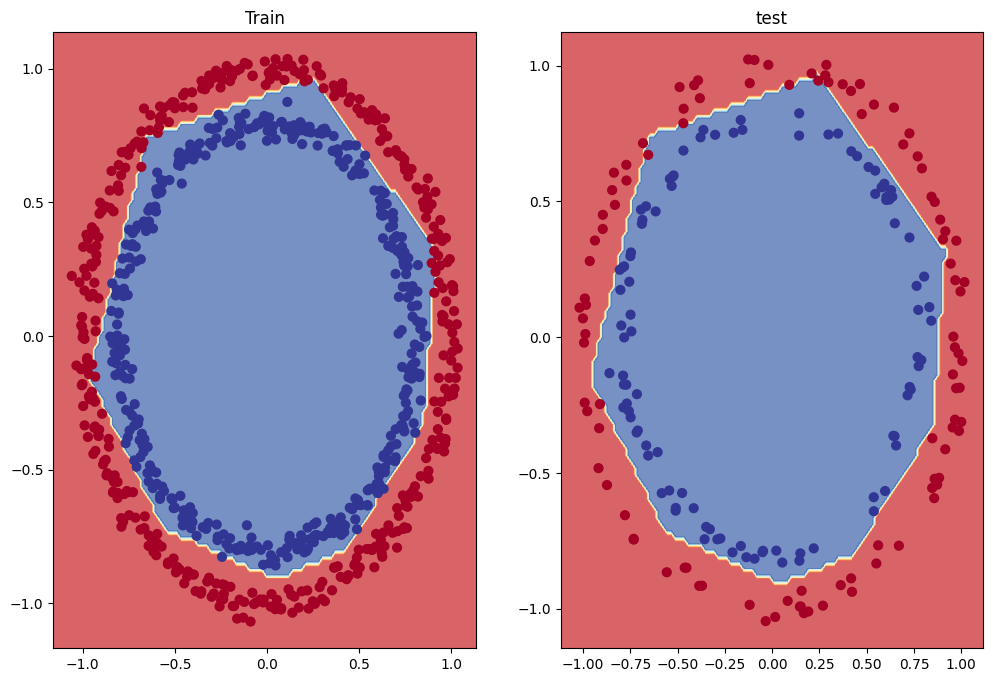

In [102]:
# plot the decision boundaries for training and test data
plt.figure(figsize=(12,8))
plt.subplot(1, 2, 1)
plt.title('Train')
plot_decision_boundary(model_10,
                       X=X_train,
                       y=y_train)
plt.subplot(1, 2, 2)
plt.title('test')
plot_decision_boundary(model_10,
                       X=X_test,
                       y=y_test)
plt.show()

### Inroducing more classification evalution metrics

Alongside visualizing our models results as much as possible, there are a beautiful handful of other classification evaluation methods & metrics you should be familiar with:

* Accurary - default, but notsuitable for imbalanced class
* Precision - Higher Precision leads to less false positive
* Recall - Higher Recall leads to less false negative
>         *Precison-Recall trade-off*
* F1-Score - harmonic mean on precision and recall
* confusion_matrix -
* classification_report from scikit-learn

In [103]:
# check the accuracy of our model
loss, accuracy = model_10.evaluate(X_test, y_test)
print(f'Model loss on test set: {loss}')
print(f'Accuracy on train set: {(accuracy*100):.2f}%')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9850 - loss: 0.0620 
Model loss on test set: 0.062014564871788025
Accuracy on train set: 98.50%


### How about a confusion matrix

In [104]:
# create a confusion matrix
from sklearn.metrics import confusion_matrix

# make predictions
y_pred = model_10.predict(X_test)

# create confusion matrix
confusion_matrix(y_test, y_pred)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [105]:
y_test[:10]

array([1, 1, 1, 1, 0, 0, 1, 0, 1, 0])

In [106]:
y_pred[:10]

array([[0.9541643 ],
       [0.9991438 ],
       [0.9699336 ],
       [0.96550864],
       [0.07188288],
       [0.00943937],
       [0.9550215 ],
       [0.01112185],
       [0.99519855],
       [0.05892258]], dtype=float32)

Oops... looks like our predictions array has come out in **prediction probability** from ... the standard output from sigmoid (or softmax) activation functions.

In [107]:
# convert prediction probabilities to binary format and check 10
tf.round(y_pred)[:10]

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.]], dtype=float32)>

In [108]:
# create confusion matrix
confusion_matrix(y_test, tf.round(y_pred))

array([[98,  3],
       [ 0, 99]])

In [109]:
from sklearn.metrics import ConfusionMatrixDisplay

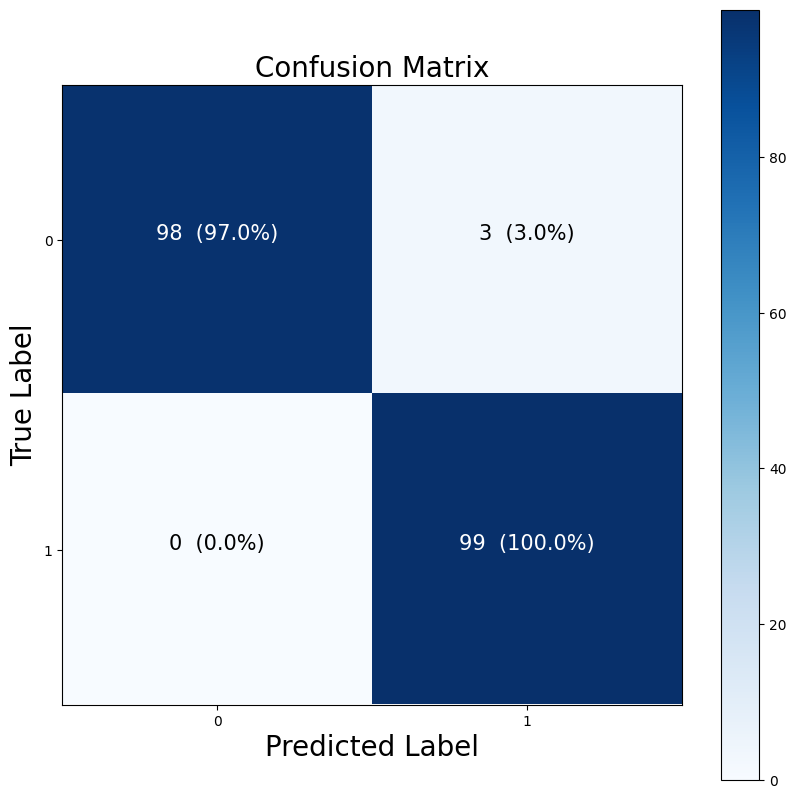

In [112]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
import itertools

figsize = (10, 10)

# create the confusion matrix
cm = confusion_matrix(y_test, tf.round(y_pred))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize our confusion matrix
n_classes = cm.shape[0]

# let's prettify it
fig, ax = plt.subplots(figsize=figsize)
# creat a matrix plot
cax = ax.matshow(cm, cmap=plt.cm.Blues)
fig.colorbar(cax)

# create classes
classes = False

if classes:
  labels = classes
else:
  labels = np.arange(cm.shape[0])

  # labe; the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted Label",
         ylabel="True Label",
         xticks=np.arange(n_classes),
         yticks=np.arange(n_classes),
         xticklabels=labels,
         yticklabels=labels)

# set x axis label to bottom
ax.xaxis.set_label_position('bottom')
ax.xaxis.tick_bottom()

# Adjust label size
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)
ax.title.set_size(20)


# set threshold for different colors
threshold = (cm.max() + cm.min()) / 2.

# plot the text on each cell
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]}  ({cm_norm[i,j]*100:.1f}%)",
             horizontalalignment='center',
             color="white" if cm[i, j] > threshold else "black",
             size=15)